# Notebook Instructions

1. If you are new to Jupyter notebooks, please go through this introductory manual <a href='https://quantra.quantinsti.com/quantra-notebook' target="_blank">here</a>.
1. Any changes made in this notebook would be lost after you close the browser window. **You can download the notebook to save your work on your PC.**
1. Before running this notebook on your local PC:<br>
i.  You need to set up a Python environment and the relevant packages on your local PC. To do so, go through the section on "**Run Codes Locally on Your Machine**" in the course.<br>
ii. You need to **download the zip file available in the last unit** of this course. The zip file contains the data files and/or python modules that might be required to run this notebook.

# Compute and Visualise Pivot Points

In the previous video, we learned about the concept of pivot points. In this notebook, you will learn to code and determine all of the important levels such as the pivot level along with the three support and resistance levels. And you will also learn to visualise the same. 

The notebook is structured as follows:
1. [Import Libraries](#libraries)
1. [Import the Data](#data)
2. [Visualise the Data](#visualise-data)
2. [Resample the Data](#resample)
3. [Get the Pivot Level](#pivot)
4. [Get the Support and Resistance Levels](#s-r-levels)
5. [Visualise the Pivot Points](#visualise)
5. [Conclusion](#conclusion)

<a id='libraries'></a>
## Import Libraries

In [1]:
# For data manipulation
import pandas as pd
import numpy as np

# For datetime manipulation
from datetime import timedelta

# For plotting
import matplotlib.pyplot as plt
%matplotlib inline

<a id='data'></a>
## Import the Data

From the `data_modules` folder, we are going to fetch the minute level data for Apple stock which ranges from Jan 2015 to Feb 2021. The name of the CSV file is `apple_1_minute_2015_2021.csv`. And this CSV file is available in the zip file of the unit 'Python Codes and Data' in the 'Course Summary' section.

We will use the `read_csv` method of `pandas` to import the data and then store it in a dataframe named `data`.

In [2]:
# Import the stock price data
data = pd.read_csv('../data_modules/apple_1_minute_2015_2021.csv', index_col=0)

# Change the index type to datetime
data.index = pd.to_datetime(data.index)

# Display the last 5 rows of the data
data.head()

,Open,High,Low,Close
2015-01-02 09:30:00+00:00,27.8475,27.8600,27.800,27.810
2015-01-02 09:31:00+00:00,27.8100,27.8475,27.785,27.825
2015-01-02 09:32:00+00:00,27.8250,27.8475,27.815,27.825
2015-01-02 09:33:00+00:00,27.8225,27.8250,27.780,27.795
2015-01-02 09:34:00+00:00,27.7950,27.8100,27.760,27.760


<a id='visualise-data'></a>
## Visualise the Data

Next, let's plot the `Close` price series for Apple's data that we imported.

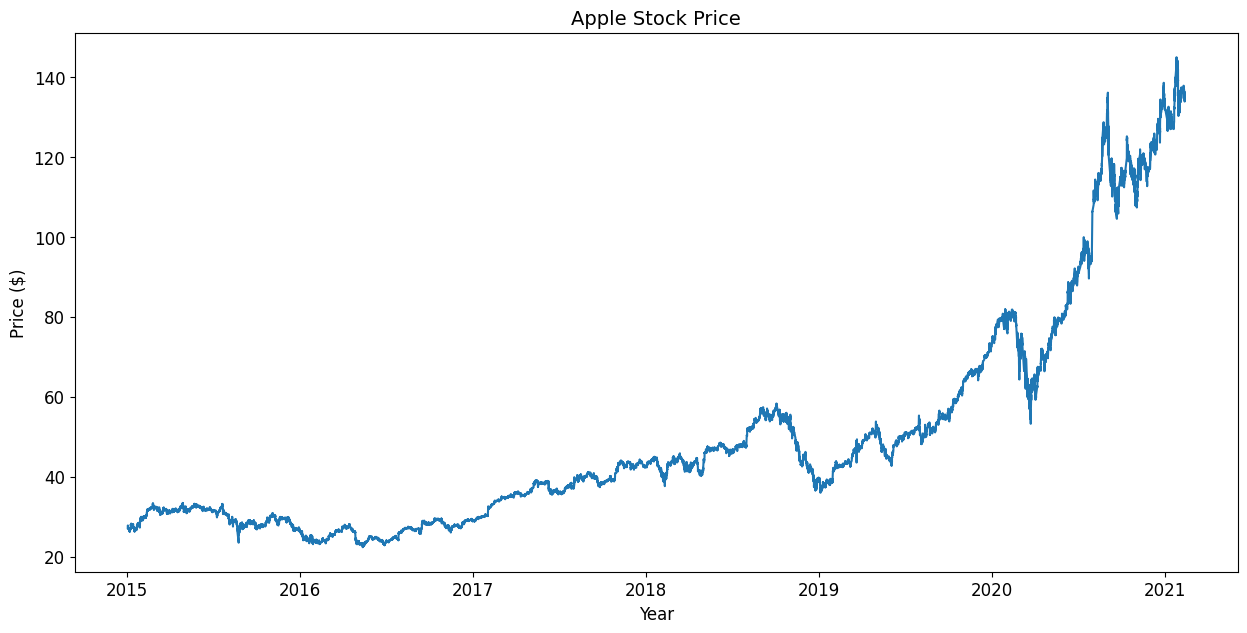

In [3]:
# Plot Apple stock's close price
plt.figure(figsize=(15, 7))
plt.plot(data['Close'])

# Set the title, axes labels and ticks
plt.title('Apple Stock Price', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.tick_params(axis='both', labelsize=12)
plt.show()

<a id='resample'></a>
## Resample the Data

The calculation of the pivot levels will be done on the daily timeframe and further, we will visualise these levels over the minute level data for a trading day. Hence, let us begin by resampling the minute level data into the daily frequency.

In [4]:
# Aggregate function
ohlcv_dict = {'Open': 'first',
              'High': 'max',
              'Low': 'min',
              'Close': 'last'
             }

# Resample the data to daily frequency
data_daily = data.resample('1d', label='left', closed='right').agg(ohlcv_dict).dropna()
data_daily.index += timedelta(hours=16, minutes=0)
data_daily.tail()

,Open,High,Low,Close
2021-02-04 16:00:00+00:00,136.34,137.584,134.59,137.39
2021-02-05 16:00:00+00:00,137.32,139.530,135.86,136.77
2021-02-09 16:00:00+00:00,136.69,137.880,135.00,136.00
2021-02-10 16:00:00+00:00,136.48,136.990,134.40,135.36
2021-02-11 16:00:00+00:00,135.92,136.390,133.57,135.12


<a id='pivot'></a>
## Get the Pivot Values

Here we're going to compute the pivot levels based on the following formula:

$P = \frac {High + Low + Close}{3}$  

Where, **P** stands for Pivot Point. 

Generally, referring to the pivot level is better than referring to the previous close as the pivot calculation also incorporates the high, low and close of the previous day. For instance, if the values of the preceding day's candle were to be as follows:

High = 270, Low = 250, and the Close = 255, then the value of the pivot level will be (270 + 250 + 255) / 3 = 258.33

Note: In the following code cell, the `shift` function has been used because we will compute the pivot level based on the preceding candle's OHLC values. Passing `1` to the `shift` function indicates that we are shifting the index axis by a period of 1 to fetch the data of the previous row (which in our case, is the previous day's candle).

In [5]:
# Define the high, low and close of the previous row
prev_high = data_daily['High'].shift(1)
prev_low = data_daily['Low'].shift(1)
prev_close = data_daily['Close'].shift(1)

# Calculate the pivot level
data_daily['Pivot'] = (prev_high + prev_low + prev_close)/3
data_daily.tail()

,Open,High,Low,Close,Pivot
2021-02-04 16:00:00+00:00,136.34,137.584,134.59,137.39,133.860000
2021-02-05 16:00:00+00:00,137.32,139.530,135.86,136.77,136.521333
2021-02-09 16:00:00+00:00,136.69,137.880,135.00,136.00,137.386667
2021-02-10 16:00:00+00:00,136.48,136.990,134.40,135.36,136.293333
2021-02-11 16:00:00+00:00,135.92,136.390,133.57,135.12,135.583333


In the above code, we have computed the values of the pivot point. 

Using the pivot point we will calculate the three support and resistance levels based on the pivot level. 

<a id='s-r-levels'></a>
## Get the Support and Resistance Values

The support and resistance levels can be computed by using the following formula:

* **R1** = 2 * P - Low <br>
* **R2** = P + (High - Low) <br>
* **R3** = P + 2 * (High - Low) <br>
<br>
* **S1** = 2 * PP - High <br>
* **S2** = P - (High - Low) <br>
* **S3** = P - 2 * (High - Low) <br>

In [6]:
# Calculate the resistance levels
data_daily['R1'] = 2 * data_daily['Pivot'] - prev_low
data_daily['R2'] = data_daily['Pivot'] + (prev_high - prev_low)
data_daily['R3'] = data_daily['Pivot'] + 2*(prev_high - prev_low)

# Calculate the support levels
data_daily['S1'] = 2 * data_daily['Pivot'] - prev_high
data_daily['S2'] = data_daily['Pivot'] - (prev_high - prev_low)
data_daily['S3'] = data_daily['Pivot'] - 2*(prev_high - prev_low)

# Drop the NaN values from the dataframe
data_daily.dropna(axis=0, how='any', inplace=True)

# Display the data
data_daily.head()

,Open,High,Low,Close,Pivot,R1,R2,R3,S1,S2,S3
2015-01-05 16:00:00+00:00,27.0725,27.1625,26.3525,26.5625,27.340833,27.844167,28.363333,29.385833,26.821667,26.318333,25.295833
2015-01-06 16:00:00+00:00,26.6700,26.8575,26.1575,26.5575,26.692500,27.032500,27.502500,28.312500,26.222500,25.882500,25.072500
2015-01-07 16:00:00+00:00,26.7950,27.0500,26.6750,26.9375,26.524167,26.890833,27.224167,27.924167,26.190833,25.824167,25.124167
2015-01-08 16:00:00+00:00,27.3075,28.0375,27.1750,27.9675,26.887500,27.100000,27.262500,27.637500,26.725000,26.512500,26.137500
2015-01-09 16:00:00+00:00,28.1675,28.3125,27.5525,28.0000,27.726667,28.278333,28.589167,29.451667,27.415833,26.864167,26.001667


Now, all of the important support and resistance levels have been calculated and stored in the respective columns in dataframe `data`.

<a id='visualise'></a>
## Visualise the Pivot Points

Next, let's visualise all of these important levels for the most recent trading date in our data. The levels can be plotted as horizontal lines over the minute close price series data of Apple stock for a recent period.

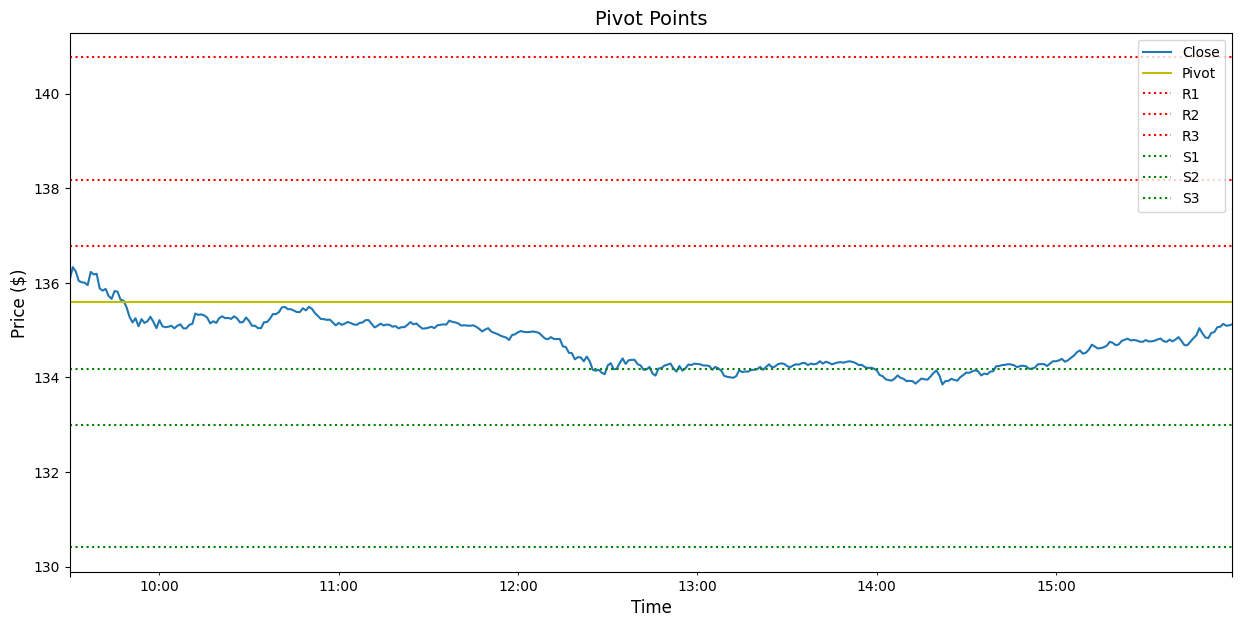

In [7]:
# Plot the close price for latest trading day
plt.figure(figsize=(15, 7))
data.iloc[-390:]['Close'].plot()

# Plot the horizontal levels based on pivot points of the previous day's data
# For pivot level
plt.axhline(data_daily.iloc[-1]['Pivot'], color='y', label="Pivot")

# For resistance levels
plt.axhline(data_daily.iloc[-1]['R1'], color='r', linestyle=':', label="R1")
plt.axhline(data_daily.iloc[-1]['R2'], color='r', linestyle=':', label="R2")
plt.axhline(data_daily.iloc[-1]['R3'], color='r', linestyle=':', label="R3")

# For support levels
plt.axhline(data_daily.iloc[-1]['S1'], color='g', linestyle=':', label="S1")
plt.axhline(data_daily.iloc[-1]['S2'], color='g', linestyle=':', label="S2")
plt.axhline(data_daily.iloc[-1]['S3'], color='g', linestyle=':', label="S3")

# Set the title and axes label
plt.title('Pivot Points', fontsize=14)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.legend()

# Show the plot
plt.show()

<a id='conclusion'></a>
## Conclusion
In this notebook, you learned how to calculate and visualise the pivot level along with the various support and resistance levels with the help of Python. Each of the support and resistance levels that were identified based on the pivot can be expected to act as a potential reversal point for the asset's price.

That's all for now. In the upcoming units, you will be introduced to some additional kinds of pivot trading systems. <br><br>